<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
features, target_class = iris.data, iris.target

# X (Maiúsculo): Representa as características (data). Usamos letra maiúscula porque na matemática isso representa uma matriz (várias colunas).

# y (Minúsculo): Representa o alvo (target). Usamos letra minúscula porque é um vetor (uma única coluna).

X_train, X_test, y_train, y_test = train_test_split(features, target_class, test_size=0.2, random_state=42, stratify=target_class)

# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [3]:
from sklearn.tree import DecisionTreeClassifier

def train(label: str, depth: int = None, criterion: str = 'gini'):
    clf = DecisionTreeClassifier(random_state=42, max_depth=depth, criterion=criterion)

    clf.fit(X_train, y_train)

    acc_train = clf.score(X_train, y_train)
    acc_test = clf.score(X_test, y_test)
    print('-' * 100)
    print(f"Árvore de decisão ({label})")
    print('-' * 100)
    print(f"Acurácia no conjunto de treino: {acc_train:.2f}") # 1.00
    print(f"Acurácia no conjunto de teste: {acc_test:.2f}") # 0.93
    print('-' * 100)
    return clf


clf = train("sem limite de profundidade")

----------------------------------------------------------------------------------------------------
Árvore de decisão (sem limite de profundidade)
----------------------------------------------------------------------------------------------------
Acurácia no conjunto de treino: 1.00
Acurácia no conjunto de teste: 0.93
----------------------------------------------------------------------------------------------------


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

[Text(0.4, 0.9166666666666666, 'petal length (cm) <= 2.45\ngini = 0.667\nsamples = 120\nvalue = [40, 40, 40]\nclass = setosa'),
 Text(0.3, 0.75, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]\nclass = setosa'),
 Text(0.35, 0.8333333333333333, 'True  '),
 Text(0.5, 0.75, 'petal width (cm) <= 1.65\ngini = 0.5\nsamples = 80\nvalue = [0, 40, 40]\nclass = versicolor'),
 Text(0.45, 0.8333333333333333, '  False'),
 Text(0.2, 0.5833333333333334, 'petal length (cm) <= 4.95\ngini = 0.133\nsamples = 42\nvalue = [0, 39, 3]\nclass = versicolor'),
 Text(0.1, 0.4166666666666667, 'gini = 0.0\nsamples = 38\nvalue = [0, 38, 0]\nclass = versicolor'),
 Text(0.3, 0.4166666666666667, 'sepal length (cm) <= 6.15\ngini = 0.375\nsamples = 4\nvalue = [0, 1, 3]\nclass = virginica'),
 Text(0.2, 0.25, 'sepal width (cm) <= 2.45\ngini = 0.5\nsamples = 2\nvalue = [0, 1, 1]\nclass = versicolor'),
 Text(0.1, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]\nclass = virginica'),
 Text(0.3, 0.08333333333333

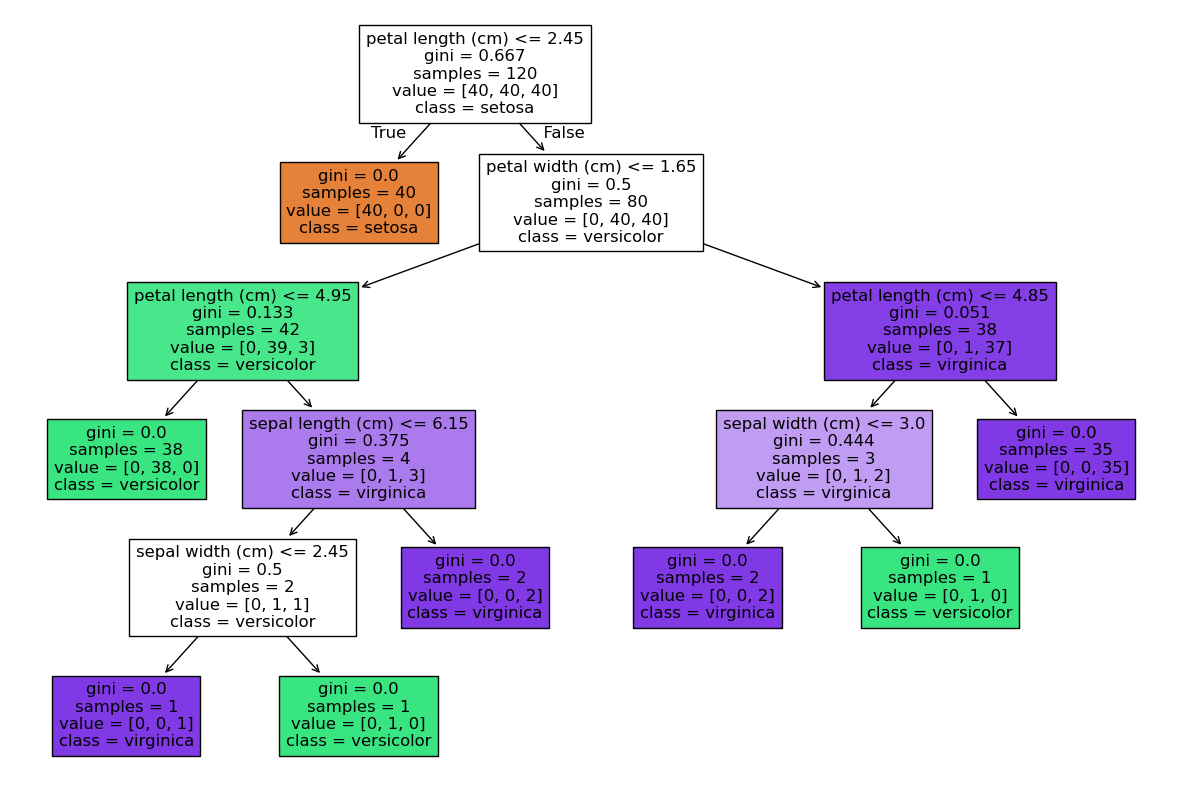

In [4]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# O tamanho da petala <= 2.45 aparece como atributo raiz
# A árvore possui 6 níveis

plt.figure(figsize=(15,10))
plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)

# O tamanho da petala <= 2.45 aparece como atributo raiz
# A árvore possui 6 níveis


# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [5]:
import pandas as pd
resultados = []

for depth in [*range(1, 10), None]:
    clf = DecisionTreeClassifier(random_state=42, max_depth=depth)
    clf.fit(X_train, y_train)
    acc_train = clf.score(X_train, y_train)
    acc_test = clf.score(X_test, y_test)
    profundidade = clf.get_depth()
    folhas = clf.get_n_leaves()
    resultados.append({
        'max_depth': depth,
        'acuracia_treino': acc_train,
        'acuracia_teste': acc_test,
        'profundidade': profundidade,
        'n_folhas': folhas
    })
df_resultados = pd.DataFrame(resultados)
display(df_resultados)

,max_depth,acuracia_treino,acuracia_teste,profundidade,n_folhas
0,1.0,0.666667,0.666667,1,2
1,2.0,0.966667,0.933333,2,3
2,3.0,0.983333,0.966667,3,5
3,4.0,0.991667,0.933333,4,7
4,5.0,1.000000,0.933333,5,8
5,6.0,1.000000,0.933333,5,8
6,7.0,1.000000,0.933333,5,8
7,8.0,1.000000,0.933333,5,8
8,9.0,1.000000,0.933333,5,8
9,NaN,1.000000,0.933333,5,8


**Em qual profundidade começa o overfitting?**
# O overfitting começa com max_depth = 5, o modelo decororou todos os dados de treino e não consegue generalizar para novos dados

**Por que a árvore consegue 100% no treino quando max_depth=None?**

# Quando definimos max_depth=None, permitimos que a árvore de decisão cresça até que todas as suas folhas fiquem "puras". Isso significa que o algoritmo continuará criando divisões e novas perguntas até que cada grupo final (folha) contenha apenas exemplos de uma única classe.

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [6]:
entropy_model = train("com critério de divisão = entropia", criterion='entropy')
gini_model = train("com critério de divisão = gini", criterion='gini')

# Profundidade
print(f"Profundidade do modelo com critério de divisão = entropia: {entropy_model.get_depth()}") # 6
print(f"Profundidade do modelo com critério de divisão = gini: {gini_model.get_depth()}") # 6

----------------------------------------------------------------------------------------------------
Árvore de decisão (com critério de divisão = entropia)
----------------------------------------------------------------------------------------------------
Acurácia no conjunto de treino: 1.00
Acurácia no conjunto de teste: 0.93
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Árvore de decisão (com critério de divisão = gini)
----------------------------------------------------------------------------------------------------
Acurácia no conjunto de treino: 1.00
Acurácia no conjunto de teste: 0.93
----------------------------------------------------------------------------------------------------
Profundidade do modelo com critério de divisão = entropia: 5
Profundidade do modelo com critério de divisão = gini: 5


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**: max_depth tem impacto na complexidade do modelo, controla o nível da árvore, max depth muito curto pode fazer o modelo sofrer underfitting e tomar decisões muito brevemente, enquanto max_depth muito profundo pode fazer com que o modelo sofra overfitting, aonde basicamente ele decora os dados de treino e nao consegue lidar bem com os dados de teste, como no exercicio anterior ao aumentar muito o parametro o modelo atinge 100% de score em treino mas nao atinge 100% score em ,teste. O melhor modelo encontrado foi com max_depth    3 que é aproximadamente log2(n) para o numero de elementos elementos no conjunto                                                                                     